# Latent Space Analysis
This notebook performs an analysis of the latent space using t-SNE (and PCA) to verify that faces of identical subjects cluster closely together.
\n

In [1]:
import sys
import os
from pathlib import Path

# Add project root to path
sys.path.append(str(Path.cwd().parent))

import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader

from src.datasets.face_dataset import CasiaFaceDataset
from src.models.resnet18 import build_baseline_resnet18

## Configuration
Setup the paths and initialize model/dataset.\n

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Assuming we are running this inside 'notebooks' folder
data_root = "../data/casia-webface/"
split_file = "../data/splits/casia_identity_split_v1.json"

# We choose max 10 identities for clearer visualization
num_identities_to_plot = 10
images_per_identity = 20

Using device: cuda


In [3]:
# Load dataset
dataset = CasiaFaceDataset(
    data_root=data_root,
    split_file=split_file,
    split_name="train", # fallback to train or val depending on split contents
    image_size=224,
    train=False,
    drop_unmapped_labels=False
)

print(f"Dataset length: {len(dataset)}")

# Filter to get a balanced subset of a few identities
from collections import defaultdict
import random

identity_to_indices = defaultdict(list)
for idx, sample in enumerate(dataset.samples):
    identity_to_indices[sample.identity_id].append(idx)

selected_identities = random.sample(list(identity_to_indices.keys()), min(num_identities_to_plot, len(identity_to_indices)))

subset_indices = []
for identity in selected_identities:
    indices = identity_to_indices[identity]
    if len(indices) > images_per_identity:
        indices = random.sample(indices, images_per_identity)
    subset_indices.extend(indices)

subset_dataset = torch.utils.data.Subset(dataset, subset_indices)
dataloader = DataLoader(subset_dataset, batch_size=32, shuffle=False, num_workers=2)
print(f"Selected {len(subset_indices)} images from {len(selected_identities)} identities.")

[dataset:train] skipped 2709 samples with missing image files.
Dataset length: 340968
Selected 189 images from 10 identities.


In [4]:
# Load model
# We load the baseline ResNet18 model initialized with ImageNet weights, 
# or you could load a fine-tuned checkpoint by modifying this variable.
LOAD_CHECKPOINT = True

model = build_baseline_resnet18(pretrained=True, embedding_dim=512, normalize_embeddings=True)
model = model.to(device)

if LOAD_CHECKPOINT:
    try:
        from src.evaluation.evaluate import _find_latest_checkpoint
        from src.utils.config import resolve_repo_path
        runs_root = resolve_repo_path("experiments/runs")
        checkpoint_path = _find_latest_checkpoint(runs_root)
        print(f"Loading checkpoint from {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        state_dict = checkpoint.get("model_state_dict", checkpoint)
        model.load_state_dict(state_dict)
    except Exception as e:
        print(f"Could not load checkpoint: {e}. Using baseline weights.")
        
model.eval()

# Extract embeddings
all_embeddings = []
all_labels = []

with torch.no_grad():
    for batch in dataloader:
        images = batch["images"].to(device)
        labels = batch["identity_id"].numpy()
        
        embeddings = model.forward_features(images)
        
        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.append(labels)

all_embeddings = np.concatenate(all_embeddings, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"Extracted {all_embeddings.shape[0]} embeddings of dimension {all_embeddings.shape[1]}")


Loading checkpoint from C:\Users\jzmat\Desktop\uni\ml-face-recognition\experiments\runs\triplet-hardmining-20260418-015950\checkpoints\best.pt


C:\Users\jzmat\AppData\Local\Temp\ipykernel_30616\1834208667.py:16: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devic

Extracted 189 embeddings of dimension 512


## t-SNE Visualization
Reduce dimensionality to 2D and visualize.\n

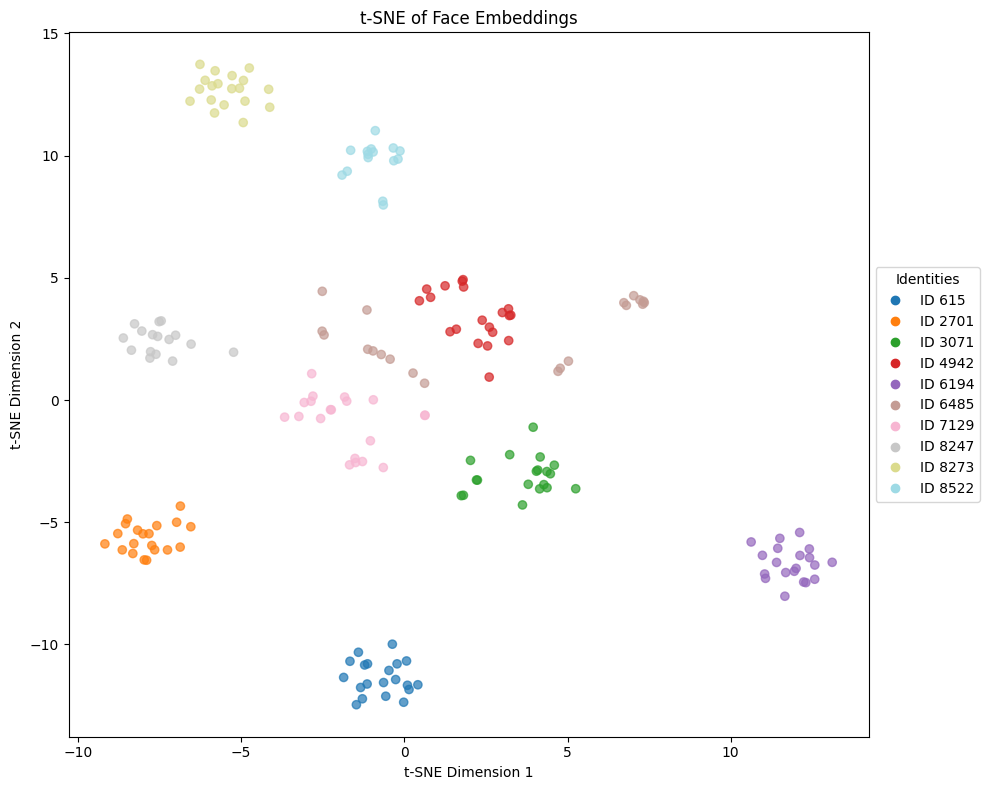

In [7]:
# Compute t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
embeddings_2d = tsne.fit_transform(all_embeddings)

# Build a deterministic identity -> color index mapping
unique_ids = np.array(sorted(np.unique(all_labels)))
id_to_color_idx = {identity: idx for idx, identity in enumerate(unique_ids)}
color_idx = np.array([id_to_color_idx[identity] for identity in all_labels])

# Use a discrete colormap with one color per identity
cmap = plt.get_cmap('tab20', len(unique_ids))

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=color_idx,
    cmap=cmap,
    alpha=0.7,
    vmin=-0.5,
    vmax=len(unique_ids) - 0.5
 )
plt.title("t-SNE of Face Embeddings")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

# Create a legend aligned with identity-color mapping
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', color=cmap(i), label=f"ID {identity}")
    for i, identity in enumerate(unique_ids)
]
plt.legend(handles=handles, title="Identities", loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()

## PCA Visualization
Compare with a simpler linear dimensionality reduction (PCA).\n

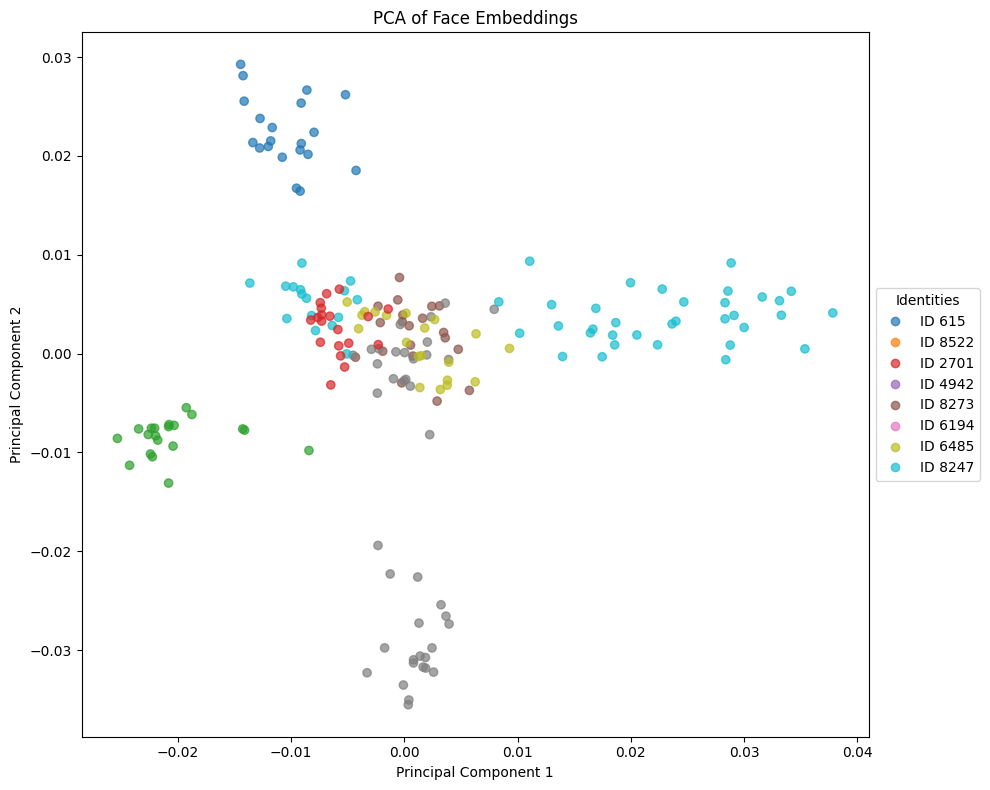

In [ ]:
# Compute PCA
pca = PCA(n_components=2, random_state=42)
embeddings_pca = pca.fit_transform(all_embeddings)

# Reuse the same deterministic identity -> color index mapping approach
unique_ids = np.array(sorted(np.unique(all_labels)))
id_to_color_idx = {identity: idx for idx, identity in enumerate(unique_ids)}
color_idx = np.array([id_to_color_idx[identity] for identity in all_labels])

# Use a discrete colormap with one color per identity
cmap = plt.get_cmap('tab20', len(unique_ids))

# Plot
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    embeddings_pca[:, 0],
    embeddings_pca[:, 1],
    c=color_idx,
    cmap=cmap,
    alpha=0.7,
    vmin=-0.5,
    vmax=len(unique_ids) - 0.5
 )
plt.title("PCA of Face Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Create a legend aligned with identity-color mapping
handles = [
    plt.Line2D([0], [0], marker='o', linestyle='', color=cmap(i), label=f"ID {identity}")
    for i, identity in enumerate(unique_ids)
]
plt.legend(handles=handles, title="Identities", loc="center left", bbox_to_anchor=(1, 0.5))

plt.tight_layout()
plt.show()